# 04 - Funnel and Marketplace Analysis

## Objective

This notebook turns the cleaned captain-level data into the main analyses required for the take-home:

- **A1–A2:** signup → approval funnel and the largest actionable leak
- **A3:** evaluation of `CAMP_WA_002`
- **B1–B2:** airport demand–supply pressure and post-airport-trip behavior

The analysis uses the cleaned captain-level dataset from Notebook 03 and the raw airport, document-event, and nudge datasets where event-level detail is needed.

**Cohorting rule:** captains who signed up within 14 days of the June 30, 2026 extraction cutoff are excluded from the primary A2O funnel because they may not have had enough time to complete onboarding. These captains remain in the underlying data and are not treated as failures.

## 1. Load the Analysis Datasets

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
captain_base = pd.read_csv(
    "../data/captain_base.csv",
    parse_dates=["signup_ts", "decision_ts", "first_order_ts"]
)

doc_events = pd.read_csv(
    "../data/doc_events.csv",
    parse_dates=["event_ts"]
)

airport_hourly = pd.read_csv(
    "../data/airport_hourly.csv",
    parse_dates=["hour_ts"]
)

airport_trips = pd.read_csv(
    "../data/airport_trips.csv",
    parse_dates=["request_ts"]
)

nudges = pd.read_csv(
    "../data/nudges.csv",
    parse_dates=["sent_ts"]
)

print(f"Captain-level rows: {len(captain_base):,}")
print(f"Document events: {len(doc_events):,}")
print(f"Airport hourly rows: {len(airport_hourly):,}")
print(f"Airport trips: {len(airport_trips):,}")
print(f"Nudge records: {len(nudges):,}")

Captain-level rows: 25,000
Document events: 186,282
Airport hourly rows: 10,248
Airport trips: 60,000
Nudge records: 16,314


## 2. Define the primary funnel cohort

The primary A2O funnel uses the `eligible_for_funnel` flag created in Notebook 03. This keeps the denominator consistent across all stages.

In [3]:
funnel = captain_base[captain_base["eligible_for_funnel"]].copy()

In [4]:
print("Total captains:", f"{len(captain_base):,}")
print("Funnel-eligible signups:", f"{len(funnel):,}")
print("Excluded as potentially censored:", f"{len(captain_base) - len(funnel):,}")

Total captains: 25,000
Funnel-eligible signups: 22,757
Excluded as potentially censored: 2,243


## 3. Build cumulative funnel stages

The stages follow the required document order: **DL → RC → Aadhaar → Permit (Auto/Cab only) → Fitness → Insurance → Approval**. A captain only reaches a stage if all preceding required stages have been cleared.

In [5]:
funnel["stage_dl"] = funnel["DL_cleared"]

In [6]:
funnel["stage_rc"] = (
    funnel["stage_dl"]
    & funnel["RC_cleared"]
)

In [7]:
funnel["stage_aadhaar"] = (
    funnel["stage_rc"]
    & funnel["AADHAAR_cleared"]
)

In [8]:
permit_required = funnel["vehicle_type"].isin(["Auto", "Cab"])

In [9]:
funnel["stage_permit"] = (
    funnel["stage_aadhaar"]
    & (
        ~permit_required
        | funnel["PERMIT_cleared"]
    )
)

In [10]:
funnel["stage_fitness"] = (
    funnel["stage_permit"]
    & funnel["FITNESS_cleared"]
)

In [11]:
funnel["stage_insurance"] = (
    funnel["stage_fitness"]
    & funnel["INSURANCE_cleared"]
)

In [12]:
funnel["stage_approved"] = (
    funnel["final_status"] == "approved"
)

In [13]:
stage_columns = [
    "stage_dl",
    "stage_rc",
    "stage_aadhaar",
    "stage_permit",
    "stage_fitness",
    "stage_insurance",
    "stage_approved",
]

In [14]:
stage_counts = funnel[stage_columns].sum()
display(stage_counts.to_frame("captains"))

,captains
stage_dl,20136
stage_rc,14647
stage_aadhaar,13093
stage_permit,10439
stage_fitness,7752
stage_insurance,4412
stage_approved,3998


In [15]:
print(f"Permit required (Auto/Cab): {permit_required.sum():,}")
print(f"Permit not required (ERickshaw): {(~permit_required).sum():,}")

Permit required (Auto/Cab): 18,416
Permit not required (ERickshaw): 4,341


## 4. A1 — Signup → Approval funnel

For each stage, we show the number of captains reaching it, the absolute loss from the previous stage, the stage-to-stage conversion, and cumulative conversion from signup.

In [16]:
funnel_table = pd.DataFrame({
    "stage": [
        "Signup",
        "DL",
        "RC",
        "Aadhaar",
        "Permit",
        "Fitness",
        "Insurance",
        "Approved",
    ],
    "captains": [
        len(funnel),
        funnel["stage_dl"].sum(),
        funnel["stage_rc"].sum(),
        funnel["stage_aadhaar"].sum(),
        funnel["stage_permit"].sum(),
        funnel["stage_fitness"].sum(),
        funnel["stage_insurance"].sum(),
        funnel["stage_approved"].sum(),
    ],
})

In [17]:
funnel_table["volume_lost"] = (
    funnel_table["captains"].shift(1) - funnel_table["captains"]
).fillna(0).astype(int)

In [18]:
funnel_table["stage_conversion_pct"] = np.where(
    funnel_table["captains"].shift(1).notna(),
    funnel_table["captains"] / funnel_table["captains"].shift(1) * 100,
    100,
)

In [19]:
funnel_table["cumulative_conversion_pct"] = (
    funnel_table["captains"] / len(funnel) * 100
)

In [20]:
display(
    funnel_table.style.format({
        "captains": "{:,.0f}",
        "volume_lost": "{:,.0f}",
        "stage_conversion_pct": "{:.1f}%",
        "cumulative_conversion_pct": "{:.1f}%",
    })
)

,stage,captains,volume_lost,stage_conversion_pct,cumulative_conversion_pct
0,Signup,"22,757",0,100.0%,100.0%
1,DL,"20,136","2,621",88.5%,88.5%
2,RC,"14,647","5,489",72.7%,64.4%
3,Aadhaar,"13,093","1,554",89.4%,57.5%
4,Permit,"10,439","2,654",79.7%,45.9%
5,Fitness,"7,752","2,687",74.3%,34.1%
6,Insurance,"4,412","3,340",56.9%,19.4%
7,Approved,"3,998",414,90.6%,17.6%


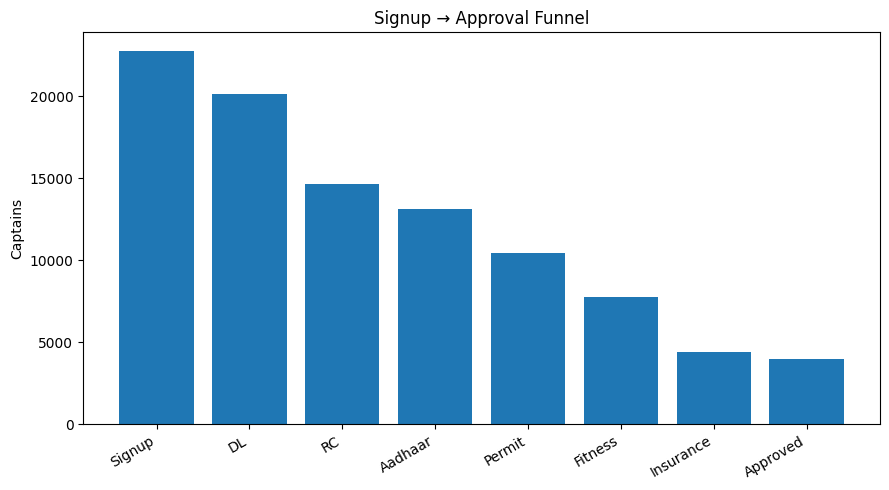

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(funnel_table["stage"], funnel_table["captains"])
plt.ylabel("Captains")
plt.title("Signup → Approval Funnel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Where is the largest captain-level leak?

The absolute drop between consecutive cumulative stages identifies where the most captains are lost. This is different from document-event failure volume, which can contain multiple attempts from the same captain.

In [22]:
dropoff = funnel_table.iloc[1:].copy()
largest_drop = dropoff.loc[dropoff["volume_lost"].idxmax()]

In [23]:
print(
    f"Largest absolute drop: {largest_drop['stage']} "
    f"({largest_drop['volume_lost']:,} captains)"
)

Largest absolute drop: RC (5,489 captains)


In [24]:
display(
    dropoff[
        ["stage", "volume_lost", "stage_conversion_pct", "cumulative_conversion_pct"]
    ].sort_values("volume_lost", ascending=False)
)

,stage,volume_lost,stage_conversion_pct,cumulative_conversion_pct
2,RC,5489,72.740366,64.362614
6,Insurance,3340,56.914345,19.387441
5,Fitness,2687,74.259987,34.064244
4,Permit,2654,79.729627,45.871600
1,DL,2621,88.482665,88.482665
3,Aadhaar,1554,89.390319,57.533946
7,Approved,414,90.616500,17.568221


### Funnel Drop-off by Stage

The funnel volume shows how many captains reach each stage, but absolute drop-off highlights where the largest number of captains are lost.

RC represents the largest captain-level drop, with 5,489 captains lost between DL and RC.

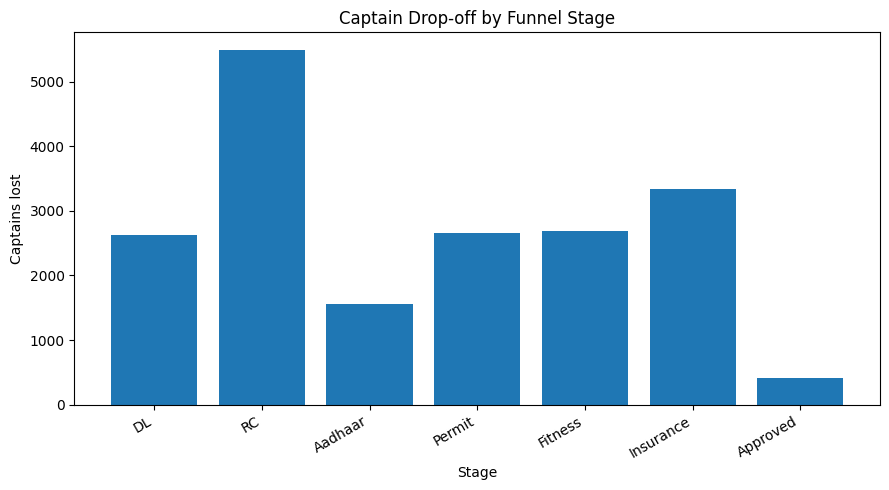

In [25]:
dropoff_plot = funnel_table.iloc[1:].copy()

plt.figure(figsize=(9, 5))
plt.bar(
    dropoff_plot["stage"],
    dropoff_plot["volume_lost"]
)
plt.xlabel("Stage")
plt.ylabel("Captains lost")
plt.title("Captain Drop-off by Funnel Stage")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5.1 Verification failure reasons

Failure reasons are examined at the event level. Because one captain can have multiple attempts, these counts describe **verification friction**, not unique captains permanently lost.

In [26]:
failure_events = doc_events[
    doc_events["event_type"] == "verification_fail"
].copy()

In [27]:
failure_summary = (
    failure_events["failure_reason"]
    .value_counts(dropna=False)
    .rename_axis("failure_reason")
    .reset_index(name="failure_events")
)

In [28]:
failure_summary["failure_share_pct"] = (
    failure_summary["failure_events"]
    / failure_summary["failure_events"].sum()
    * 100
)

In [29]:
display(failure_summary)

,failure_reason,failure_events,failure_share_pct
0,image_blurred,4767,24.109852
1,ocr_low_confidence,3696,18.693101
2,name_mismatch,3173,16.047947
3,document_expired,2686,13.584867
4,details_not_legible,2171,10.980174
5,wrong_document_type,2083,10.535100
6,duplicate_document,1196,6.048958


## 5.2 Verification failures by document

In [30]:
failure_by_doc = (
    failure_events
    .groupby("doc_type")
    .size()
    .reset_index(name="failure_events")
)

In [31]:
failure_by_doc["failure_share_pct"] = (
    failure_by_doc["failure_events"]
    / failure_by_doc["failure_events"].sum()
    * 100
)

In [32]:
display(
    failure_by_doc.sort_values("failure_events", ascending=False)
)

,doc_type,failure_events,failure_share_pct
5,RC,8174,41.341291
1,DL,3408,17.236496
2,FITNESS,2693,13.620271
3,INSURANCE,2126,10.752579
4,PERMIT,1921,9.715760
0,AADHAAR,1450,7.333603


In [33]:
display(
    pd.crosstab(
        failure_events["doc_type"],
        failure_events["failure_reason"]
    )
)

failure_reason,details_not_legible,document_expired,duplicate_document,image_blurred,name_mismatch,ocr_low_confidence,wrong_document_type
doc_type,,,,,,,
AADHAAR,164,233,107,266,304,196,180
DL,428,531,239,624,693,497,396
FITNESS,281,301,150,750,386,574,251
INSURANCE,272,244,106,569,304,417,214
PERMIT,189,467,141,270,362,239,253
RC,837,910,453,2288,1124,1773,789


## 5.3 Segment the largest funnel leak

The RC stage is examined across city, vehicle, acquisition channel, and device tier. We report both the number lost and the drop-off rate among captains who reached DL, so large segments are not automatically mistaken for high-risk segments.

In [34]:
def stage_dropoff_by_segment(df, group_col, previous_stage, current_stage):
    grouped = (
        df.groupby(group_col)
        .agg(
            previous_stage=(previous_stage, "sum"),
            current_stage=(current_stage, "sum"),
        )
        .reset_index()
    )

    grouped["dropoff"] = (
        grouped["previous_stage"] - grouped["current_stage"]
    )

    grouped["dropoff_rate_pct"] = np.where(
        grouped["previous_stage"] > 0,
        grouped["dropoff"] / grouped["previous_stage"] * 100,
        np.nan,
    )

    return grouped.sort_values("dropoff", ascending=False)

In [35]:
rc_by_city = stage_dropoff_by_segment(
    funnel, "city", "stage_dl", "stage_rc"
)
rc_by_vehicle = stage_dropoff_by_segment(
    funnel, "vehicle_type", "stage_dl", "stage_rc"
)
rc_by_channel = stage_dropoff_by_segment(
    funnel, "acquisition_channel", "stage_dl", "stage_rc"
)
rc_by_device = stage_dropoff_by_segment(
    funnel, "device_tier", "stage_dl", "stage_rc"
)

In [36]:
display(rc_by_city)

,city,previous_stage,current_stage,dropoff,dropoff_rate_pct
2,Hyderabad,6151,4444,1707,27.751585
1,Delhi,5211,3810,1401,26.885435
0,Bangalore,4372,3167,1205,27.561757
3,Pune,4402,3226,1176,26.715129


In [37]:
display(rc_by_vehicle)

,vehicle_type,previous_stage,current_stage,dropoff,dropoff_rate_pct
0,Auto,9144,6667,2477,27.088801
1,Cab,7153,5169,1984,27.736614
2,ERickshaw,3839,2811,1028,26.777807


In [38]:
display(rc_by_channel)

,acquisition_channel,previous_stage,current_stage,dropoff,dropoff_rate_pct
2,organic_app,6670,4790,1880,28.185907
4,referral,4437,3159,1278,28.803245
0,fos_field,5239,4110,1129,21.549914
3,paid_digital,2656,1776,880,33.132530
1,gc_telecalling,1134,812,322,28.395062


In [39]:
display(rc_by_device)

,device_tier,previous_stage,current_stage,dropoff,dropoff_rate_pct
1,low,9279,6235,3044,32.805259
2,mid,7739,5929,1810,23.388035
0,high,3118,2483,635,20.365619


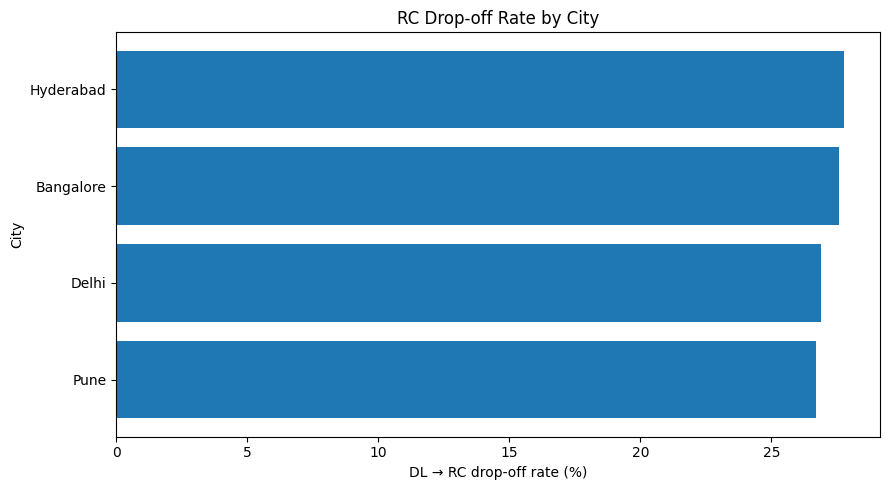

In [40]:
rc_city_plot = rc_by_city.sort_values("dropoff_rate_pct")

plt.figure(figsize=(9, 5))
plt.barh(
    rc_city_plot["city"],
    rc_city_plot["dropoff_rate_pct"]
)
plt.xlabel("DL → RC drop-off rate (%)")
plt.ylabel("City")
plt.title("RC Drop-off Rate by City")
plt.tight_layout()
plt.show()

## 5.4 Attempt and recovery analysis

A failed document attempt does not necessarily mean permanent loss. For each captain-document pair, we identify whether a failure occurred and whether that document was eventually cleared in a later attempt.

In [41]:
doc_attempts = (
    doc_events
    .groupby(["captain_id", "doc_type"])
    .agg(
        max_attempt=("attempt_no", "max"),
        passed=("event_type", lambda x: (x == "verification_pass").any()),
        failed=("event_type", lambda x: (x == "verification_fail").any()),
    )
    .reset_index()
)

In [42]:
failed_docs = doc_attempts[doc_attempts["failed"]].copy()

In [43]:
recovery_summary = (
    failed_docs
    .groupby("doc_type")
    .agg(
        failed_document_instances=("failed", "sum"),
        eventually_cleared=("passed", "sum"),
    )
    .reset_index()
)

In [44]:
recovery_summary["recovery_rate_pct"] = (
    recovery_summary["eventually_cleared"]
    / recovery_summary["failed_document_instances"]
    * 100
)

In [45]:
display(
    recovery_summary.sort_values("recovery_rate_pct", ascending=False)
)

,doc_type,failed_document_instances,eventually_cleared,recovery_rate_pct
0,AADHAAR,1439,894,62.126477
1,DL,3308,2011,60.792019
4,PERMIT,1744,1027,58.887615
2,FITNESS,2362,1369,57.959356
3,INSURANCE,1785,966,54.117647
5,RC,6702,3344,49.895554


## 5.5 RC failure modes and recovery

RC is the largest captain-level drop-off, so its failure reasons are examined separately. The recovery calculation is descriptive: it identifies failure modes where subsequent clearance is observed, but it does not estimate the effect of a specific intervention.

In [46]:
rc_failures = doc_events[
    (doc_events["doc_type"] == "RC")
    & (doc_events["event_type"] == "verification_fail")
].copy()

In [47]:
rc_failure_reasons = (
    rc_failures["failure_reason"]
    .value_counts(dropna=False)
    .rename_axis("failure_reason")
    .reset_index(name="failure_events")
)

In [48]:
rc_failure_reasons["failure_share_pct"] = (
    rc_failure_reasons["failure_events"]
    / rc_failure_reasons["failure_events"].sum()
    * 100
)

In [49]:
display(rc_failure_reasons)

,failure_reason,failure_events,failure_share_pct
0,image_blurred,2288,27.991192
1,ocr_low_confidence,1773,21.690727
2,name_mismatch,1124,13.750918
3,document_expired,910,11.132860
4,details_not_legible,837,10.239785
5,wrong_document_type,789,9.652557
6,duplicate_document,453,5.541962


In [50]:
rc_attempts = (
    doc_events[doc_events["doc_type"] == "RC"]
    .groupby(["captain_id", "doc_type"])
    .agg(
        max_attempt=("attempt_no", "max"),
        passed=("event_type", lambda x: (x == "verification_pass").any()),
        failed=("event_type", lambda x: (x == "verification_fail").any()),
    )
    .reset_index()
)

In [51]:
rc_failed_instances = rc_attempts[rc_attempts["failed"]].copy()

In [52]:
rc_first_failure = (
    doc_events[
        (doc_events["doc_type"] == "RC")
        & (doc_events["event_type"] == "verification_fail")
    ]
    .sort_values(["captain_id", "event_ts"])
    .drop_duplicates("captain_id")
    [["captain_id", "failure_reason"]]
)

In [53]:
rc_recovery_by_reason = (
    rc_failed_instances
    .merge(rc_first_failure, on="captain_id", how="left", validate="one_to_one")
    .groupby("failure_reason")
    .agg(
        failed_instances=("failed", "sum"),
        eventually_cleared=("passed", "sum"),
    )
    .reset_index()
)

In [54]:
rc_recovery_by_reason["recovery_rate_pct"] = (
    rc_recovery_by_reason["eventually_cleared"]
    / rc_recovery_by_reason["failed_instances"]
    * 100
)

In [55]:
display(
    rc_recovery_by_reason.sort_values(
        ["failed_instances", "recovery_rate_pct"],
        ascending=[False, False],
    )
)

,failure_reason,failed_instances,eventually_cleared,recovery_rate_pct
3,image_blurred,1842,891,48.371336
5,ocr_low_confidence,1421,689,48.486981
4,name_mismatch,960,510,53.125000
1,document_expired,759,398,52.437418
0,details_not_legible,676,348,51.479290
6,wrong_document_type,666,328,49.249249
2,duplicate_document,378,180,47.619048


## 5.6 RC image/OCR opportunity pool

Image-quality and OCR-related failures are grouped as a potential intervention pool. This is **not** treated as an estimate of recoverable approvals; it is the population that could be targeted in an experiment.

In [56]:
image_ocr_reasons = ["image_blurred", "ocr_low_confidence"]

In [57]:
image_ocr_instances = rc_recovery_by_reason[
    rc_recovery_by_reason["failure_reason"].isin(image_ocr_reasons)
].copy()

In [58]:
image_ocr_failed = image_ocr_instances["failed_instances"].sum()
image_ocr_recovered = image_ocr_instances["eventually_cleared"].sum()

In [59]:
print(f"RC image/OCR failed instances: {image_ocr_failed:,}")
print(f"Eventually cleared: {image_ocr_recovered:,}")

RC image/OCR failed instances: 3,263
Eventually cleared: 1,580


In [60]:
display(image_ocr_instances)

,failure_reason,failed_instances,eventually_cleared,recovery_rate_pct
3,image_blurred,1842,891,48.371336
5,ocr_low_confidence,1421,689,48.486981


## 5.7 A2 - Illustrative RC recovery scenario

To translate the RC leak into an approval opportunity, we can model a simple scenario: **10% of current RC drop-offs are recovered**, with recovered captains converting to approval at the current observed RC → approval rate.

This is a sensitivity scenario, not a forecast or causal estimate.

In [61]:
rc_to_approval_rate = (
    funnel["stage_approved"].sum()
    / funnel["stage_rc"].sum()
)

In [62]:
rc_dropoff_count = (
    funnel["stage_dl"].sum()
    - funnel["stage_rc"].sum()
)

### Scenario assumption

For scenario sizing, we assume a **10% recovery of the identified RC drop-off**. This is an illustrative planning scenario, not a causal forecast; the actual recovery rate should be validated through a controlled product/ops experiment.

In [63]:
scenario_recovered = rc_dropoff_count * 0.10
scenario_additional_approvals = (
    scenario_recovered * rc_to_approval_rate
)

In [64]:
print(f"RC → approved conversion: {rc_to_approval_rate * 100:.1f}%")
print(f"Current RC drop-off: {rc_dropoff_count:,}")
print(f"10% recovery scenario: {scenario_recovered:,.0f} captains")
print(f"Illustrative additional approvals: {scenario_additional_approvals:,.0f}")

RC → approved conversion: 27.3%
Current RC drop-off: 5,489
10% recovery scenario: 549 captains
Illustrative additional approvals: 150


# Notebook 4 — Part 1: Funnel & Onboarding Analysis — Final Conclusion

## 1. Purpose

This part of Notebook 4 converts the cleaned captain-level dataset from Notebook 3 into the primary onboarding funnel analysis required for A1 and A2.

The analysis focuses on the mature funnel cohort, identifies cumulative stage conversion and captain-level drop-off, and then investigates the largest actionable leak in greater detail.

---

## 2. Primary Funnel Cohort

The underlying captain-level dataset contains **25,000 signups**.

To avoid treating recent signups as onboarding failures, the primary funnel uses the `eligible_for_funnel` flag created in Notebook 3. Captains require at least **14 days of observable time** after signup to enter the mature funnel.

This results in:

* **22,757 funnel-eligible signups**
* **2,243 potentially right-censored signups**

The 2,243 excluded captains remain in the underlying data and are not treated as failures.

---

## 3. Cumulative Onboarding Funnel

The onboarding journey was represented as a cumulative sequence:

**Signup → DL → RC → Aadhaar → Permit → Fitness → Insurance → Approval**

A captain only reaches a stage if all preceding required stages have been cleared.

The Permit stage also respects the business rule that Permit is required for **Auto and Cab**, but not for **ERickshaw**.

The mature-cohort funnel contains:

| Stage     | Captains | Stage Conversion | Cumulative Conversion |
| --------- | -------: | ---------------: | --------------------: |
| Signup    |   22,757 |           100.0% |                100.0% |
| DL        |   20,136 |            88.5% |                 88.5% |
| RC        |   14,647 |            72.7% |                 64.4% |
| Aadhaar   |   13,093 |            89.4% |                 57.5% |
| Permit    |   10,439 |            79.7% |                 45.9% |
| Fitness   |    7,752 |            74.3% |                 34.1% |
| Insurance |    4,412 |            56.9% |                 19.4% |
| Approved  |    3,998 |            90.6% |                 17.6% |

The final mature-cohort **Signup → Approval (A2O) conversion is 17.6%**.

---

## 4. Largest Captain-Level Leak — A2

The largest absolute drop occurs between **DL and RC**.

* Captains reaching DL: **20,136**
* Captains reaching RC: **14,647**
* Captains lost: **5,489**
* DL → RC conversion: **72.7%**

Therefore, the RC transition is the largest captain-level funnel leak and the primary area selected for deeper investigation.

This is measured using cumulative captain-level stages rather than raw document-event counts.

---

## 5. Why Event-Level Failure Counts Must Be Interpreted Carefully

Document verification failures were analyzed separately from captain-level funnel drop-off.

The distinction is important because a single captain can generate multiple document events through repeated attempts. For example, one captain may fail RC twice and eventually pass it, creating multiple failure events but only one captain-level outcome.

Therefore:

> **Verification failure-event volume represents verification friction, not the number of captains permanently lost from the funnel.**

Failure reasons and failure volume by document are consequently used as diagnostic evidence rather than as direct estimates of lost captains.

---

## 6. RC Failure Investigation

Because RC is the largest captain-level leak, RC verification failures were examined separately.

The analysis evaluates:

* RC failure reasons
* failure-event volume
* failure share
* recovery after failure
* failure reason versus eventual recovery
* image/OCR-related failure opportunities

The recovery analysis is descriptive. It identifies cases where a document failed and was subsequently cleared, but it does not establish that a particular intervention caused the recovery.

---

## 7. Segmentation of the RC Leak

The RC drop-off was segmented across:

* **City**
* **Vehicle type**
* **Acquisition channel**
* **Device tier**

For each segment, both absolute drop-off and drop-off rate among captains who reached DL are reported.

This prevents a large segment from being incorrectly interpreted as the highest-risk segment simply because it contains more captains.

The analysis therefore distinguishes between:

> **Where the largest number of captains are lost**

and:

> **Where the highest proportion of DL-reaching captains are lost.**

---

## 8. Recovery and Image/OCR Opportunity

Failed document instances were evaluated for eventual recovery in later attempts.

The analysis also groups `image_blurred` and `ocr_low_confidence` RC failures into an image/OCR opportunity pool.

This pool should not be interpreted as guaranteed recoverable approvals. It represents a population that could reasonably be targeted for an intervention or experiment.

---

## 9. Illustrative A2 Recovery Scenario

A sensitivity scenario assumes that **10% of the current RC drop-off could be recovered**.

The current RC drop-off is:

**5,489 captains**

A 10% recovery would therefore correspond to approximately:

**549 recovered captains**

The observed RC → Approval conversion is approximately:

**27.3%**

Applying this observed conversion rate to the illustrative recovery pool gives approximately:

**150 additional approvals**

This is explicitly a **scenario**, not a forecast or causal estimate.

---

## 10. Key Numerical Takeaways

| Metric                            |            Result |
| --------------------------------- | ----------------: |
| Total signups                     |        **25,000** |
| Funnel-eligible signups           |        **22,757** |
| Potentially right-censored        |         **2,243** |
| Mature-cohort approvals           |         **3,998** |
| Mature-cohort A2O                 |         **17.6%** |
| Largest leak                      |       **DL → RC** |
| Captains lost at DL → RC          |         **5,489** |
| DL → RC conversion                |         **72.7%** |
| RC → Approval conversion          |        **~27.3%** |
| Illustrative RC recovery          | **~549 captains** |
| Illustrative additional approvals |          **~150** |

---

## 11. What We Now Understand

Part 1 establishes that the onboarding problem is not simply a low overall A2O percentage.

The mature funnel shows several meaningful losses, with the largest absolute captain-level loss occurring at **DL → RC**, where **5,489 captains** are lost.

The analysis then separates three different concepts that should not be conflated:

1. **Captain-level funnel drop-off**
2. **Document verification failure events**
3. **Recovery after a failed document attempt**

This distinction allows the RC problem to be investigated without overstating what the raw failure events prove.

---

## 12. Handover to Part 2

Part 1 establishes the onboarding funnel and identifies RC as the largest captain-level leak.

Part 2 moves beyond the onboarding funnel into:

* **R2A — Approval → First Order**
* campaign evaluation for **CAMP_WA_002**
* airport demand–supply pressure
* hourly airport mismatch
* post-airport-trip captain behavior

These analyses answer the remaining business questions and allow the final recommendations to connect onboarding, activation, campaigns, and marketplace supply.


## 6. R2A - Approval → First Order

R2A is measured among all approved captains. Missing `first_order_ts` is treated as not having completed a first order in the available data.

In [65]:
approved = captain_base[
    captain_base["final_status"] == "approved"
].copy()

In [66]:
approved["first_order_completed"] = approved["first_order_ts"].notna()

In [67]:
r2a_rate = approved["first_order_completed"].mean() * 100

In [68]:
print(f"Approved captains: {len(approved):,}")
print(f"Approved with first order: {approved['first_order_completed'].sum():,}")
print(f"Approved without first order: {(~approved['first_order_completed']).sum():,}")
print(f"R2A conversion: {r2a_rate:.1f}%")

Approved captains: 4,206
Approved with first order: 4,104
Approved without first order: 102
R2A conversion: 97.6%


In [69]:
time_to_first_order = approved.loc[
    approved["first_order_completed"],
    "approval_to_first_order_days"
]

display(time_to_first_order.describe())

count    4104.000000
mean        1.714744
std         1.365636
min         0.001303
25%         0.721890
50%         1.374499
75%         2.364522
max        11.068693
Name: approval_to_first_order_days, dtype: float64

### R2A by acquisition channel

In [70]:
r2a_by_channel = (
    approved
    .groupby("acquisition_channel")
    .agg(
        approved_captains=("captain_id", "count"),
        first_orders=("first_order_completed", "sum"),
    )
    .reset_index()
)

In [71]:
r2a_by_channel["r2a_rate_pct"] = (
    r2a_by_channel["first_orders"]
    / r2a_by_channel["approved_captains"]
    * 100
)

In [72]:
display(r2a_by_channel.sort_values("r2a_rate_pct"))

,acquisition_channel,approved_captains,first_orders,r2a_rate_pct
1,gc_telecalling,206,199,96.601942
3,paid_digital,341,330,96.774194
0,fos_field,1586,1539,97.036570
2,organic_app,1220,1198,98.196721
4,referral,853,838,98.241501


### R2A by city

In [73]:
r2a_by_city = (
    approved
    .groupby("city")
    .agg(
        approved_captains=("captain_id", "count"),
        first_orders=("first_order_completed", "sum"),
    )
    .reset_index()
)

In [74]:
r2a_by_city["r2a_rate_pct"] = (
    r2a_by_city["first_orders"]
    / r2a_by_city["approved_captains"]
    * 100
)

In [75]:
display(r2a_by_city.sort_values("r2a_rate_pct"))

,city,approved_captains,first_orders,r2a_rate_pct
2,Hyderabad,1264,1225,96.914557
1,Delhi,1206,1172,97.180763
0,Bangalore,897,879,97.993311
3,Pune,839,828,98.688915


## 7. B1 - Airport demand–supply mismatch

The airport datasets cover May–June 2026. The hourly dataset is used to quantify unfulfilled demand and identify where and when pressure is concentrated.

In [76]:
terminal_mask = airport_hourly["zone_id"].isin(["APT-T1", "APT-T2"])
airport_terminal = airport_hourly[terminal_mask].copy()

In [77]:
total_requests = airport_terminal["requests"].sum()
total_fulfilled = airport_terminal["fulfilled_requests"].sum()
total_unfulfilled = airport_terminal["unfulfilled_requests"].sum()

In [78]:
terminal_fulfillment_rate = total_fulfilled / total_requests * 100
terminal_unfulfilled_rate = total_unfulfilled / total_requests * 100

In [79]:
print(f"Terminal requests: {total_requests:,}")
print(f"Fulfilled: {total_fulfilled:,}")
print(f"Unfulfilled: {total_unfulfilled:,}")
print(f"Fulfillment rate: {terminal_fulfillment_rate:.1f}%")
print(f"Unfulfilled rate: {terminal_unfulfilled_rate:.1f}%")
print(f"Average ETA: {airport_terminal['avg_eta_min'].mean():.2f} min")
print(f"Average surge: {airport_terminal['avg_surge_multiplier'].mean():.2f}x")

Terminal requests: 136,814
Fulfilled: 81,756
Unfulfilled: 55,058
Fulfillment rate: 59.8%
Unfulfilled rate: 40.2%
Average ETA: 5.75 min
Average surge: 1.41x


### Supply pressure by zone

In [80]:
supply_by_zone = (
    airport_hourly
    .groupby(["zone_id", "zone_type"])
    .agg(
        requests=("requests", "sum"),
        fulfilled_requests=("fulfilled_requests", "sum"),
        unfulfilled_requests=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean"),
    )
    .reset_index()
)

In [81]:
supply_by_zone["unfulfilled_rate_pct"] = (
    supply_by_zone["unfulfilled_requests"]
    / supply_by_zone["requests"]
    * 100
)

In [82]:
display(
    supply_by_zone.sort_values("unfulfilled_rate_pct", ascending=False)
)

,zone_id,zone_type,requests,fulfilled_requests,unfulfilled_requests,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct
1,APT-T2,airport_terminal,68555,40865,27690,29.670765,5.763490,1.408299,40.390927
0,APT-T1,airport_terminal,68259,40891,27368,29.901639,5.735594,1.403730,40.094347
4,SUB-07,suburban,51833,50070,1763,31.282104,3.722705,1.043661,3.401308
5,SUB-11,suburban,51444,49739,1705,31.284153,3.643245,1.043545,3.314283
6,TECH-03,tech_park,61388,59531,1857,41.204918,3.654529,1.036926,3.025021
3,CBD-02,city_core,78052,76067,1985,45.265710,3.689146,1.039740,2.543176
2,CBD-01,city_core,78079,76106,1973,45.153005,3.667145,1.041728,2.526928


### Supply pressure by hour at airport terminals

In [83]:
airport_terminal["hour"] = airport_terminal["hour_ts"].dt.hour

In [84]:
terminal_by_hour = (
    airport_terminal
    .groupby("hour")
    .agg(
        requests=("requests", "sum"),
        fulfilled_requests=("fulfilled_requests", "sum"),
        unfulfilled_requests=("unfulfilled_requests", "sum"),
        avg_online_captains=("online_captains", "mean"),
        avg_eta_min=("avg_eta_min", "mean"),
        avg_surge=("avg_surge_multiplier", "mean"),
    )
    .reset_index()
)

In [85]:
terminal_by_hour["unfulfilled_rate_pct"] = (
    terminal_by_hour["unfulfilled_requests"]
    / terminal_by_hour["requests"]
    * 100
)

In [86]:
display(
    terminal_by_hour.sort_values("unfulfilled_rate_pct", ascending=False)
)

,hour,requests,fulfilled_requests,unfulfilled_requests,avg_online_captains,avg_eta_min,avg_surge,unfulfilled_rate_pct
23,23,13007,3413,9594,12.565574,10.041393,2.165246,73.760283
1,1,11288,3143,8145,12.844262,9.826230,2.146066,72.156272
22,22,11188,3146,8042,13.024590,9.900164,2.142951,71.880586
0,0,9124,2933,6191,12.598361,9.540328,2.073033,67.854011
2,2,9500,3073,6427,13.213115,9.577541,2.061557,67.652632
21,21,7293,2946,4347,13.344262,8.769426,1.926230,59.605101
3,3,6190,2916,3274,13.221311,8.005902,1.800574,52.891761
4,4,4718,3219,1499,14.983607,6.175410,1.470574,31.771937
6,6,6776,4832,1944,21.844262,5.881066,1.433770,28.689492
5,5,5291,3839,1452,17.581967,5.831967,1.408443,27.442827


In [87]:
hourly_plot = terminal_by_hour.sort_values("hour")

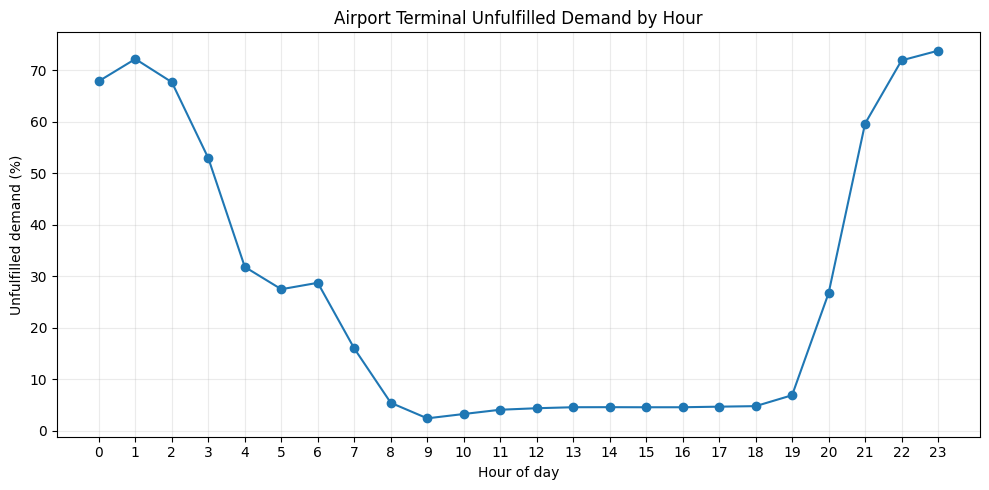

In [88]:
plt.figure(figsize=(10, 5))
plt.plot(
    hourly_plot["hour"],
    hourly_plot["unfulfilled_rate_pct"],
    marker="o",
)
plt.xlabel("Hour of day")
plt.ylabel("Unfulfilled demand (%)")
plt.title("Airport Terminal Unfulfilled Demand by Hour")
plt.xticks(range(24))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. B2 - Post airport trip captain behavior

All records in `airport_trips` originate from airport terminals, so there is no non-airport pickup control group in this dataset. Instead, we compare destination types to understand how the airport trip ends may be associated with cancellation and the chance of a return fare within 20 minutes.

In [89]:
print("Unique pickup zones:", sorted(airport_trips["pickup_zone_id"].unique()))
print(
    "All trips airport-originating:",
    airport_trips["pickup_zone_id"].str.startswith("APT-").all()
)

Unique pickup zones: ['APT-T1', 'APT-T2']
All trips airport-originating: True


In [90]:
total_trips = len(airport_trips)
cancelled_trips = airport_trips["captain_cancelled"].sum()
return_fare_trips = airport_trips["got_return_fare_within_20min"].sum()

In [91]:
print(f"Airport trips: {total_trips:,}")
print(f"Captain-cancelled: {cancelled_trips:,} ({cancelled_trips / total_trips * 100:.1f}%)")
print(
    f"Return fare within 20 min: {return_fare_trips:,} "
    f"({return_fare_trips / total_trips * 100:.1f}%)"
)

Airport trips: 60,000
Captain-cancelled: 8,260 (13.8%)
Return fare within 20 min: 21,576 (36.0%)


In [92]:
trip_by_destination = (
    airport_trips
    .groupby("drop_zone_type")
    .agg(
        trips=("trip_id", "count"),
        cancelled_trips=("captain_cancelled", "sum"),
        return_fare_trips=("got_return_fare_within_20min", "sum"),
        avg_distance_km=("trip_distance_km", "mean"),
        avg_fare_inr=("fare_inr", "mean"),
    )
    .reset_index()
)

In [93]:
trip_by_destination["cancellation_rate_pct"] = (
    trip_by_destination["cancelled_trips"]
    / trip_by_destination["trips"]
    * 100
)

In [94]:
trip_by_destination["return_fare_rate_pct"] = (
    trip_by_destination["return_fare_trips"]
    / trip_by_destination["trips"]
    * 100
)

In [95]:
display(trip_by_destination)

,drop_zone_type,trips,cancelled_trips,return_fare_trips,avg_distance_km,avg_fare_inr,cancellation_rate_pct,return_fare_rate_pct
0,city_core,25282,2181,13329,13.237335,216.623092,8.626691,52.721304
1,suburban,24643,5176,4073,23.376524,353.565475,21.003936,16.528020
2,tech_park,10075,903,4174,16.104781,255.227792,8.962779,41.429280


### B2 interpretation

The destination split is descriptive. In particular, a low return-fare rate can indicate weaker immediate utilization after an airport trip, but the dataset does not establish that this causes cancellations or airport supply shortages.

In [96]:
display(
    trip_by_destination[
        [
            "drop_zone_type",
            "trips",
            "cancellation_rate_pct",
            "return_fare_rate_pct",
            "avg_distance_km",
            "avg_fare_inr",
        ]
    ].sort_values("return_fare_rate_pct")
)

,drop_zone_type,trips,cancellation_rate_pct,return_fare_rate_pct,avg_distance_km,avg_fare_inr
1,suburban,24643,21.003936,16.528020,23.376524,353.565475
2,tech_park,10075,8.962779,41.429280,16.104781,255.227792
0,city_core,25282,8.626691,52.721304,13.237335,216.623092


## 9. A3 - Evaluate `CAMP_WA_002`

The key question is whether the available data supports the campaign's claimed 5× scaling. The analysis first establishes campaign timing, then compares approval outcomes for a cohort with enough time for an 8-day exposure window.

Because campaign assignment was observational rather than randomized, the comparison is an estimate of association, not a causal experiment.

In [97]:
camp_wa_002 = nudges[
    nudges["campaign_id"] == "CAMP_WA_002"
].copy()

In [98]:
print(f"CAMP_WA_002 records: {len(camp_wa_002):,}")
print(f"Unique captains: {camp_wa_002['captain_id'].nunique():,}")

CAMP_WA_002 records: 8,673
Unique captains: 8,673


In [99]:
print("Channel:")
display(camp_wa_002["channel"].value_counts())

Channel:


channel
whatsapp    8673
Name: count, dtype: int64

In [100]:
print("Delivery:")
display(camp_wa_002["delivered"].value_counts(dropna=False))

Delivery:


delivered
1    8058
0     615
Name: count, dtype: int64

In [101]:
print("Clicks:")
display(camp_wa_002["clicked"].value_counts(dropna=False))

Clicks:


clicked
0    5104
1    3569
Name: count, dtype: int64

### Campaign timing relative to approval

In [102]:
campaign_timing = camp_wa_002.merge(
    captain_base[
        [
            "captain_id",
            "signup_ts",
            "decision_ts",
            "final_status",
            "eligible_for_funnel",
        ]
    ],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [103]:
campaign_timing["hours_after_signup"] = (
    campaign_timing["sent_ts"] - campaign_timing["signup_ts"]
).dt.total_seconds() / 3600

In [104]:
campaign_timing["hours_before_decision"] = (
    campaign_timing["decision_ts"] - campaign_timing["sent_ts"]
).dt.total_seconds() / 3600

In [105]:
pre_decision_campaign = campaign_timing[
    campaign_timing["hours_before_decision"] > 0
].copy()

In [106]:
print(f"Sent before signup: {(campaign_timing['hours_after_signup'] < 0).sum():,}")
print(f"Sent after signup: {(campaign_timing['hours_after_signup'] >= 0).sum():,}")
print(f"Sent before approval decision: {len(pre_decision_campaign):,}")
print(f"Sent after/on decision: {(campaign_timing['hours_before_decision'] <= 0).sum():,}")

Sent before signup: 0
Sent after signup: 8,673
Sent before approval decision: 2,727
Sent after/on decision: 0


In [107]:
display(
    pre_decision_campaign["hours_after_signup"]
    .describe()
    .to_frame("hours_after_signup")
)

,hours_after_signup
count,2727.000000
mean,56.679044
std,20.710358
min,13.700235
25%,41.989234
50%,53.631199
75%,68.377675
max,184.939012


### 8 day exposure comparison cohort

We restrict to captains whose decision occurred at least 8 days after signup. This gives both exposed and unexposed captains the same 8-day opportunity window before the decision.

In [108]:
comparison = captain_base[
    captain_base["decision_ts"].notna()
    & (
        (
            captain_base["decision_ts"] - captain_base["signup_ts"]
        ).dt.total_seconds() / 86400 >= 8
    )
].copy()

In [109]:
campaign_8d = camp_wa_002.merge(
    captain_base[
        ["captain_id", "signup_ts", "decision_ts", "final_status"]
    ],
    on="captain_id",
    how="left",
    validate="one_to_one",
)

In [110]:
campaign_8d["days_after_signup"] = (
    campaign_8d["sent_ts"] - campaign_8d["signup_ts"]
).dt.total_seconds() / 86400

In [111]:
exposed_ids = set(
    campaign_8d.loc[
        campaign_8d["days_after_signup"].between(0, 8, inclusive="both"),
        "captain_id",
    ]
)

In [112]:
comparison["campaign_exposed"] = comparison["captain_id"].isin(exposed_ids)

In [113]:
print(f"Comparison cohort: {len(comparison):,}")
display(comparison["campaign_exposed"].value_counts())

Comparison cohort: 675


campaign_exposed
True     395
False    280
Name: count, dtype: int64

### Approval outcome

In [114]:
approval_comparison = (
    comparison
    .groupby("campaign_exposed")["final_status"]
    .agg(
        captains="size",
        approved=lambda x: (x == "approved").sum(),
    )
    .reset_index()
)

In [115]:
approval_comparison["approval_rate_pct"] = (
    approval_comparison["approved"]
    / approval_comparison["captains"]
    * 100
)

In [116]:
display(approval_comparison)

,campaign_exposed,captains,approved,approval_rate_pct
0,False,280,256,91.428571
1,True,395,358,90.632911


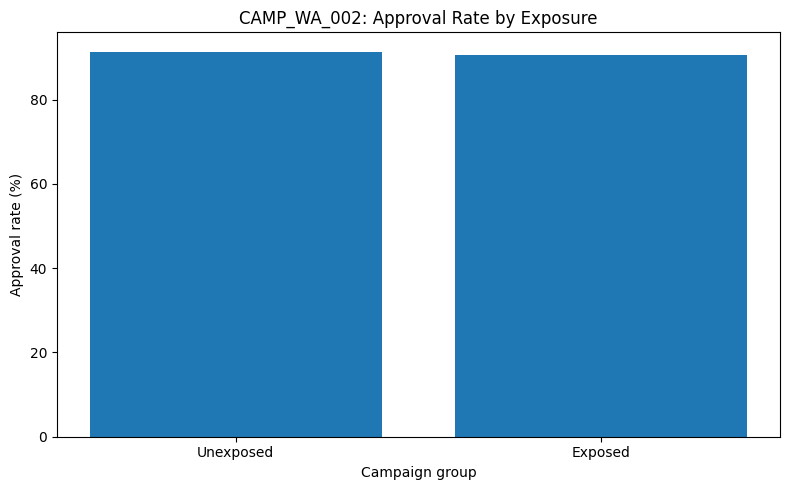

In [117]:
campaign_plot = approval_comparison.copy()

campaign_plot["group"] = campaign_plot["campaign_exposed"].map({
    True: "Exposed",
    False: "Unexposed"
})

plt.figure(figsize=(8, 5))
plt.bar(
    campaign_plot["group"],
    campaign_plot["approval_rate_pct"]
)
plt.xlabel("Campaign group")
plt.ylabel("Approval rate (%)")
plt.title("CAMP_WA_002: Approval Rate by Exposure")
plt.tight_layout()
plt.show()

### Raw approval difference and confidence interval

In [118]:
treated = comparison[comparison["campaign_exposed"]]
control = comparison[~comparison["campaign_exposed"]]

In [119]:
p_treated = (treated["final_status"] == "approved").mean()
p_control = (control["final_status"] == "approved").mean()

In [120]:
n_treated = len(treated)
n_control = len(control)

In [121]:
diff = p_treated - p_control

In [122]:
se = math.sqrt(
    p_treated * (1 - p_treated) / n_treated
    + p_control * (1 - p_control) / n_control
)

In [123]:
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

In [124]:
print(f"Observed approval difference: {diff * 100:+.2f} pp")
print(f"95% CI: {ci_low * 100:+.2f} pp to {ci_high * 100:+.2f} pp")

Observed approval difference: -0.80 pp
95% CI: -5.16 pp to +3.56 pp


### Comparability check

We compare exposed and unexposed groups on city, acquisition channel, and device tier. Matching on overlapping strata is a diagnostic for imbalance; it does not turn the observational analysis into a randomized experiment.

In [125]:
for col in [
    "city",
    "vehicle_type",
    "acquisition_channel",
    "device_tier",
    "app_language",
    "age_band",
]:
    print(f"--- {col} ---")
    display(
        pd.crosstab(
            comparison[col],
            comparison["campaign_exposed"],
            normalize="columns",
        ).mul(100).round(2)
    )

--- city ---


campaign_exposed,False,True
city,,
Bangalore,24.29,23.29
Delhi,23.21,23.04
Hyderabad,33.57,30.38
Pune,18.93,23.29


--- vehicle_type ---


campaign_exposed,False,True
vehicle_type,,
Auto,50.36,50.63
Cab,39.64,38.99
ERickshaw,10.00,10.38


--- acquisition_channel ---


...

campaign_exposed,False,True
device_tier,,
high,15.00,15.95
low,40.36,44.05
mid,44.64,40.00


--- app_language ---


campaign_exposed,False,True
app_language,,
en,24.29,20.00
hi,19.29,16.96
kn,21.79,24.05
mr,16.07,19.75
te,18.57,19.24


--- age_band ---


campaign_exposed,False,True
age_band,,
18-24,19.64,20.76
25-34,41.07,42.78
35-44,26.43,27.34
45+,12.86,9.11


In [126]:
strata_cols = ["city", "acquisition_channel", "device_tier"]

In [127]:
overlap = (
    comparison
    .groupby(strata_cols)["campaign_exposed"]
    .nunique()
)

In [128]:
overlap_strata = overlap[overlap == 2].index

In [129]:
matched_population = (
    comparison
    .set_index(strata_cols)
    .loc[overlap_strata]
    .reset_index()
)

In [130]:
standardized = (
    matched_population
    .groupby("campaign_exposed")
    .agg(
        captains=("captain_id", "size"),
        approved=("final_status", lambda x: (x == "approved").sum()),
    )
)

In [131]:
standardized["approval_rate"] = (
    standardized["approved"] / standardized["captains"]
)

In [132]:
std_diff = (
    standardized.loc[True, "approval_rate"]
    - standardized.loc[False, "approval_rate"]
)

In [133]:
print(f"Total strata: {len(overlap):,}")
print(f"Strata with both groups: {(overlap == 2).sum():,}")
print(f"Strata with one group only: {(overlap == 1).sum():,}")
print(f"Captains in overlapping strata: {len(matched_population):,}")
print(f"Approval-rate difference in overlapping strata: {std_diff * 100:+.2f} pp")

Total strata: 59
Strata with both groups: 50
Strata with one group only: 9
Captains in overlapping strata: 652
Approval-rate difference in overlapping strata: +0.19 pp


In [134]:
display(standardized)

,captains,approved,approval_rate
campaign_exposed,,,
False,276,252,0.913043
True,376,344,0.914894


### Campaign exposure summary

In [135]:
print(f"Total CAMP_WA_002 recipients: {len(camp_wa_002):,}")
print(f"Pre-decision recipients: {len(pre_decision_campaign):,}")
print(
    f"Pre-decision share: "
    f"{len(pre_decision_campaign) / len(camp_wa_002) * 100:.1f}%"
)
print(
    f"Recipient share of all captains: "
    f"{len(camp_wa_002) / len(captain_base) * 100:.1f}%"
)

Total CAMP_WA_002 recipients: 8,673
Pre-decision recipients: 2,727
Pre-decision share: 31.4%
Recipient share of all captains: 34.7%


In [136]:
comparison["days_to_decision"] = (
    comparison["decision_ts"] - comparison["signup_ts"]
).dt.total_seconds() / 86400

display(
    comparison
    .groupby("campaign_exposed")["days_to_decision"]
    .agg(["count", "mean", "median"])
    .round(2)
)

,count,mean,median
campaign_exposed,,,
False,280,9.10,8.88
True,395,9.04,8.84


# Notebook 4 — Funnel & Marketplace Analysis — Final Conclusion

## 1. Purpose

Notebook 4 converts the cleaned captain-level data into the primary business analyses for onboarding, activation, campaign performance, and airport marketplace pressure.

The analysis covers:

* A1 — Signup → Approval funnel
* A2 — Largest actionable onboarding leak
* A3 — CAMP_WA_002 evaluation
* R2A — Approval → First Order
* B1 — Airport demand–supply mismatch
* B2 — Post-airport-trip behavior

---

## 2. Mature Onboarding Cohort

The underlying dataset contains **25,000 signups**.

To avoid treating recent signups as failures, the primary onboarding funnel uses the 14-day observation rule established in Notebook 3.

This produces:

* **22,757 funnel-eligible signups**
* **2,243 potentially right-censored signups**

The right-censored captains are excluded from the primary funnel rather than being classified as onboarding failures.

---

## 3. A1 — Signup → Approval Funnel

The mature onboarding funnel is:

| Stage     | Captains | Stage Conversion | Cumulative Conversion |
| --------- | -------: | ---------------: | --------------------: |
| Signup    |   22,757 |           100.0% |                100.0% |
| DL        |   20,136 |            88.5% |                 88.5% |
| RC        |   14,647 |            72.7% |                 64.4% |
| Aadhaar   |   13,093 |            89.4% |                 57.5% |
| Permit    |   10,439 |            79.7% |                 45.9% |
| Fitness   |    7,752 |            74.3% |                 34.1% |
| Insurance |    4,412 |            56.9% |                 19.4% |
| Approval  |    3,998 |            90.6% |                 17.6% |

The mature-cohort **Signup → Approval conversion is 17.6%**.

---

## 4. A2 — Largest Captain-Level Leak

The largest absolute captain-level loss occurs between **DL and RC**.

* DL-reaching captains: **20,136**
* RC-reaching captains: **14,647**
* Captains lost: **5,489**
* DL → RC conversion: **72.7%**

RC is therefore the primary funnel stage selected for deeper investigation.

Importantly, this is a captain-level funnel loss and should not be equated directly with the number of RC verification-failure events.

---

## 5. RC Failure and Recovery Analysis

Document failures were analyzed at the event level because a single captain can have multiple attempts.

The analysis therefore distinguishes:

* verification failure events
* captain-document instances
* eventual recovery after failure
* captain-level funnel drop-off

RC failure reasons were examined separately because RC represents the largest cumulative funnel leak.

Image-quality and OCR-related RC failures were grouped into a potential intervention pool.

This pool represents captains or document instances that could potentially be targeted in an experiment; it is not an estimate of guaranteed recoverable approvals.

---

## 6. Illustrative RC Recovery Scenario

A sensitivity scenario assumes that **10% of the current RC drop-off is recovered**.

Current RC drop-off:

**5,489 captains**

Illustrative recovery:

**~549 captains**

Observed RC → Approval conversion:

**~27.3%**

Illustrative additional approvals:

**~150**

This is a sensitivity scenario rather than a causal forecast.

---

## 7. R2A — Approval → First Order

Among the **4,206 approved captains**:

* **4,104** have a recorded first order
* **102** do not have a recorded first order

This gives an R2A conversion of approximately:

**97.6%**

The high R2A rate indicates that the dominant bottleneck in this dataset is earlier in the lifecycle — getting captains through onboarding to approval — rather than converting approved captains into their first order.

The notebook also examines time from approval to first order and segments R2A by acquisition channel and city.

---

## 8. B1 — Airport Demand–Supply Mismatch

The airport analysis uses the May–June 2026 airport marketplace window and focuses on terminal zones `APT-T1` and `APT-T2`.

The analysis measures:

* total requests
* fulfilled requests
* unfulfilled requests
* fulfillment rate
* unfulfilled rate
* average ETA
* average surge

Supply pressure is then examined by:

* zone
* hour of day

The hourly analysis identifies periods in which unfulfilled demand is concentrated, providing a more actionable view of airport marketplace pressure than a single aggregate metric.

---

## 9. B2 — Post-Airport-Trip Behavior

The airport trip dataset contains **60,000 airport-originating trips**.

The analysis examines:

* captain cancellations
* destination type
* return fare within 20 minutes
* average trip distance
* average fare

Destination-level differences are descriptive.

Because all trips originate from airport terminals and there is no non-airport pickup control group, the analysis cannot establish that destination type causes cancellations, weaker utilization, or airport supply shortages.

---

## 10. A3 — CAMP_WA_002

The campaign analysis evaluates whether the available data supports the claimed **5× scaling** of `CAMP_WA_002`.

Because campaign exposure was observational rather than randomized, the comparison estimates association rather than a causal treatment effect.

To improve comparability, the analysis:

1. establishes campaign timing relative to signup and approval,
2. restricts the comparison to captains with at least an 8-day signup-to-decision window,
3. identifies captains exposed during the first 8 days,
4. compares approval rates between exposed and unexposed groups,
5. calculates the observed approval-rate difference,
6. calculates a 95% confidence interval,
7. checks composition across city, vehicle type, acquisition channel, device tier, language, and age,
8. evaluates overlapping strata.

The observed campaign comparison does **not show a detectable approval lift**, and the confidence interval spans zero.

Therefore, the available evidence **does not support a 5× scale-up**.

If the campaign remains strategically attractive, the appropriate next step is a randomized holdout experiment among eligible pre-decision captains, using approval lift as the primary outcome.

---

## 11. Key Numerical Takeaways

| Metric                            |      Result |
| --------------------------------- | ----------: |
| Total signups                     |  **25,000** |
| Funnel-eligible signups           |  **22,757** |
| Potentially right-censored        |   **2,243** |
| Mature-cohort approvals           |   **3,998** |
| Mature-cohort A2O                 |   **17.6%** |
| Largest funnel leak               | **DL → RC** |
| DL → RC captains lost             |   **5,489** |
| DL → RC conversion                |   **72.7%** |
| Raw approved captains             |   **4,206** |
| Approved with first order         |   **4,104** |
| Approved without first order      |     **102** |
| R2A                               |  **~97.6%** |
| Airport trips                     |  **60,000** |
| Illustrative RC recovery          |    **~549** |
| Illustrative additional approvals |    **~150** |

---

## 12. Overall Business Interpretation

The analysis points to a clear prioritization.

The largest onboarding opportunity is **not post-approval activation**, because approximately **97.6% of approved captains have a recorded first order**.

Instead, the largest captain-level loss occurs at **DL → RC**, where **5,489 mature-cohort captains** are lost.

This makes RC the strongest candidate for operational investigation and experimentation.

The analysis also identifies airport demand pressure as a separate marketplace problem and finds that `CAMP_WA_002` does not currently have sufficient observational evidence to justify the claimed 5× scale-up.

---

## 13. Recommended Decision Logic

The findings suggest three distinct actions:

### Onboarding

Prioritize the **DL → RC transition**, especially interventions addressing observable RC friction such as image-quality and OCR-related failures.

### Airport

Use the hourly demand–supply analysis to target captain supply toward the specific periods where unfulfilled demand is concentrated rather than treating airport supply as uniformly constrained throughout the day.

### Campaign

Do **not** scale `CAMP_WA_002` by 5× based on the current observational evidence. If the campaign is strategically attractive, validate it using a randomized holdout experiment.

---

## 14. Final Handover

Notebook 4 converts the cleaned data into the core decision evidence for the take-home.

The main conclusions are:

1. **A2O is 17.6% in the mature cohort.**
2. **DL → RC is the largest captain-level leak, with 5,489 captains lost.**
3. **R2A is approximately 97.6%, so post-approval activation is comparatively strong.**
4. **Airport supply pressure varies by time and location and should be addressed through targeted supply deployment.**
5. **CAMP_WA_002 does not show a detectable approval lift, so the available evidence does not support 5× scaling.**
6. **A randomized experiment is the appropriate next step if the campaign is to be evaluated further.**

Notebook 4 therefore moves the project from data preparation to concrete business decisions: **where to intervene, where to deploy supply, and where more rigorous experimentation is required.**
